In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **LIBRARIES**


---





In [ ]:
!pip install scikeras #Install SciKeras library

# ================================
# Libraries for data manipulation
# ================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ===============================
# Libraries for image processing
# ===============================
import cv2
from PIL import Image

# ==================================
# Libraries for file system operations
# ==================================
import shutil
import os, random

# =====================================
# Libraries for neural network models
# =====================================
import tensorflow as tf
import keras as ke
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization

# ===========================================
# Libraries for model evaluation and validation
# ===========================================
import sklearn.metrics as skm
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.utils import class_weight



## Identifying the paths that lead to the images and their labels.

In [ ]:
image_dir = '/content/drive/MyDrive/Colab Notebooks/AULA VIVI CARLA/TRABALHO_FINAL/IMG_MODOB/CLASSES'
# Lists for image paths and labels
image_paths = []
labels = []

#Identifies in the directories the paths to each of the images and their associated labels
for class_name in os.listdir(image_dir):
    class_path = os.path.join(image_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            # Image paths
            img_path = os.path.join(class_path, img_name)
            image_paths.append(img_path)
            #Labels
            labels.append(class_name)

#Converts the Python list into a NumPy array
image_paths = np.array(image_paths)
labels = np.array(labels)

In [ ]:
images = [Image.open(caminho) for caminho in image_paths] #Upload images to a list

np.shape(images[0])
np.shape(labels)
np.shape(images[0])

(364, 408, 3)

## Resize images and replace labels with binary numbers (0 and 1)


*   0: Benign
*   1: Malign

In [ ]:
#Labels to number
mapping = {'classe_b': 0, 'classe_m': 1}
labels = np.array([mapping[label] for label in labels])

print(labels)  # Exibe os rótulos numéricos

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]


(198, 224, 224, 3)

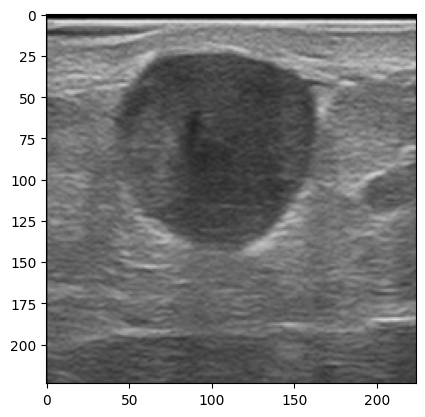

In [ ]:
new_size = (224, 224)

images = [img.resize(new_size) for img in images] #Resize
images = [np.array(img) for img in images] #Images to NumPy array
images = [(img - 0) / (255.0 - 0) for img in images] #Pixel value normalization
images = np.array(images)

plt.imshow(images[11])
np.shape(images)

## Dataset separation for the training (78%), test (10%) and validation (18%) datasets

Nº train data: (142, 224, 224, 3)
Nº test data: (20, 224, 224, 3)
Nº validation data: (36, 224, 224, 3)
0


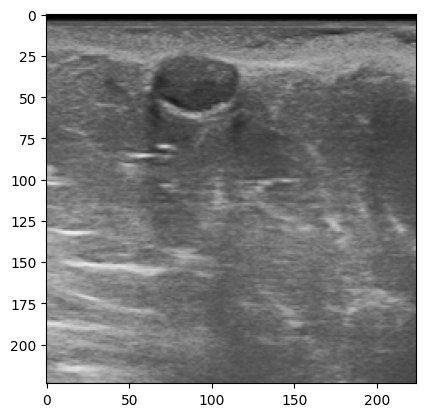

In [ ]:
#Split 10% of the data for test data
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.10, random_state=42, stratify=labels)

#Split 20% of the data for validation data
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42, stratify=y_train)
print('Nº train data:',np.shape(X_train))
print('Nº test data:',np.shape(X_test))
print('Nº validation data:',np.shape(X_val))

plt.imshow(X_train[10])
print(y_train[10])

## **Convolutional Neural Network (CNN) with MLP Architecture:**

The implemented architecture consists of a convolutional neural network with two sequential convolutional layers containing 16 and 32 filters, respectively. Both layers use ReLU activation functions and are followed by 3×3 max pooling layers. After feature extraction, the output is flattened and passed to a multilayer perceptron (MLP) composed of a single dense layer with 10 neurons and ReLU activation, followed by an output layer with a single neuron and sigmoid activation for binary classification.

In [ ]:
#=============================
#Fix state for reproducibility
#=============================

i=42
os.environ['PYTHONHASHSEED']=str(i)
tf.random.set_seed(i)
np.random.seed(i)
random.seed(i)

#=========================================================
# Calculate class weights for penalising the cost function
#=========================================================

weights=class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

#=============
#Network Model
#=============

model = Sequential()

#Convolutional and Max Pooling layers

model.add(Conv2D(16, kernel_size=(5, 5),activation='relu',input_shape=(224, 224, 3), padding='same'))
model.add(MaxPooling2D((3, 3),padding='same'))
model.add(Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same'))
model.add(MaxPooling2D((3, 3),padding='same'))

model.add(Flatten())

#MLP Network
model.add(Dense(10, activation='relu')) #16
model.add(Dense(1, activation='sigmoid'))

model.summary()

# Optimiser with exponential decay

opt = ke.optimizers.Adam(learning_rate= ke.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.00008,
    decay_steps= 15, #15
    decay_rate=0.85)) #85


model.compile(optimizer=opt,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ====================
# Save initial weights
# ====================

with open("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/initial_weights.txt", "w") as f:
    for layer in model.layers:
        pesos = layer.get_weights()
        f.write(f"Layer: {layer.name}\n")
        for p in pesos:
            f.write(str(p.tolist()) + "\n")
        f.write("\n")

batch_size = 32
epochs = 100

history= model.fit(X_train, y_train, batch_size=batch_size,epochs=epochs,verbose=1,class_weight={0:weights[0], 1:weights[1]},validation_data=(X_val, y_val))

# ==================
# Save final weights
# ==================

with open("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/final_weights.txt", "w") as f:
    for layer in model.layers:
        pesos = layer.get_weights()
        f.write(f"Layer: {layer.name}\n")
        for p in pesos:
            f.write(str(p.tolist()) + "\n")
        f.write("\n")

# ==============================
# Save loss and accuracy history
# ==============================
with open("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/history_train.txt", "w") as f:
    f.write("Epoch\tLoss\tAccuracy\tVal_Loss\tVal_Accuracy\n")
    for epoch in range(len(history.history['loss'])):
        f.write(f"{epoch+1}\t{history.history['loss'][epoch]:.6f}\t"
                f"{history.history['accuracy'][epoch]:.6f}\t"
                f"{history.history['val_loss'][epoch]:.6f}\t"
                f"{history.history['val_accuracy'][epoch]:.6f}\n")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       200,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,069 (836.21 KB)

 Trainable params: 214,069 (836.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3985 - loss: 0.6995 - val_accuracy: 0.3333 - val_loss: 0.7023
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3505 - loss: 0.6943 - val_accuracy: 0.3333 - val_loss: 0.7026
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3505 - loss: 0.6918 - val_accuracy: 0.3333 - val_loss: 0.7033
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3505 - loss: 0.6906 - val_accuracy: 0.3333 - val_loss: 0.6994
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3792 - loss: 0.6872 - val_accuracy: 0.3889 - val_loss: 0.6921
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4868 - loss: 0.6836 - val_accuracy: 0.5278 - val_loss: 0.6864
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5859 - loss: 0.6813 - val_accuracy: 0.6389 - val_loss: 0.6823
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6324 - loss: 0.6771 - val_accuracy: 0.6111 - val_loss: 

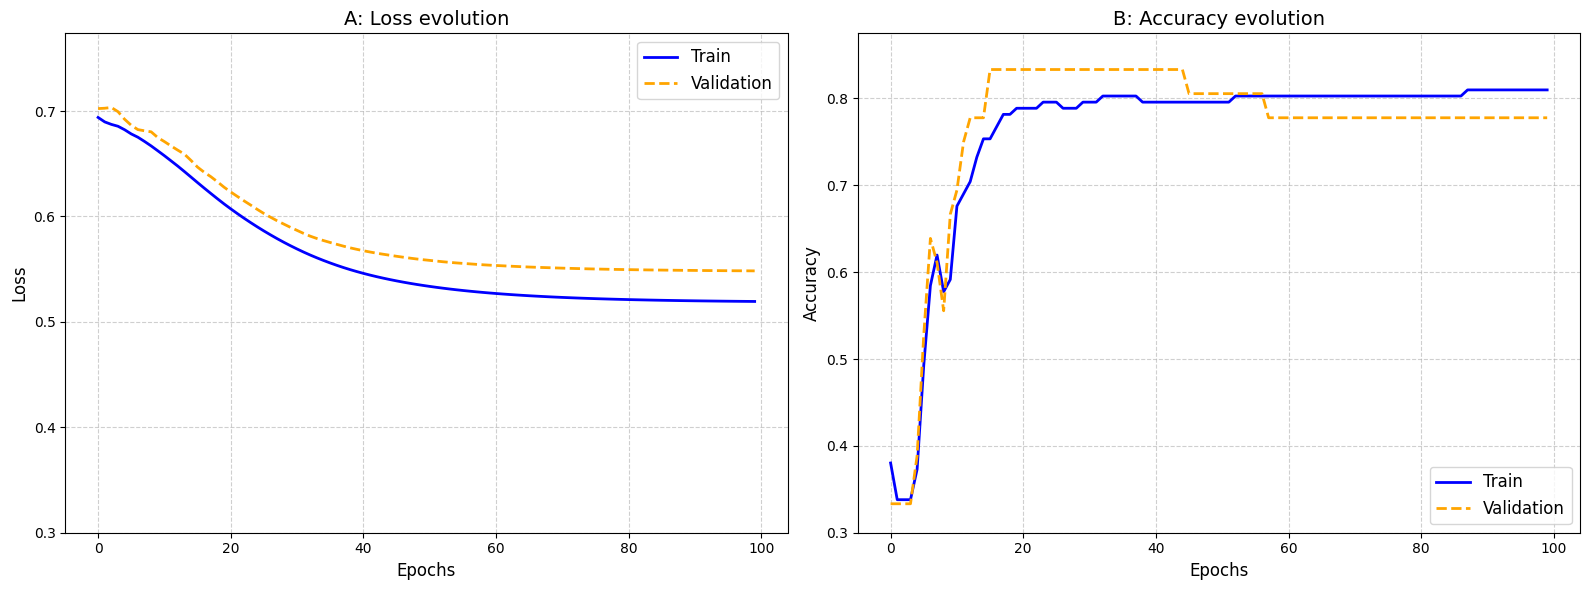

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/history_train.txt", sep="\t")

plt.figure(figsize=(16, 6))

#===========#
#Loss graph #
#===========#

plt.subplot(1, 2, 1)
plt.plot(df["Loss"], label="Train", color="blue", linewidth=2)
plt.plot(df["Val_Loss"], label="Validation", color="orange", linestyle="--", linewidth=2)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("A: Loss evolution", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.ylim([0.3, max(df["Loss"].max(), df["Val_Loss"].max()) * 1.1])

#===============
# Accuracy graph
#===============

plt.subplot(1, 2, 2)
plt.plot(df["Accuracy"], label="Train", color="blue", linewidth=2)
plt.plot(df["Val_Accuracy"], label="Validation", color="orange", linestyle="--", linewidth=2)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("B: Accuracy evolution", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.ylim([0.3, df[["Accuracy", "Val_Accuracy"]].max().max() * 1.05])


plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/grafico_TREINOVALIDACAO.jpeg", format="jpeg", dpi=300)

plt.show()

## **Cross-validation (k-folds)**

The model was validated using stratified k-fold cross-validation with 5 splits (k=5), ensuring a more robust assessment of its performance.

In [ ]:
#=============================
#Fix state for reproducibility
#=============================

i = 42
os.environ['PYTHONHASHSEED'] = str(i)
tf.random.set_seed(i)
np.random.seed(i)
random.seed(i)

#=======================================#
# Train and validation data concatenate #
# ======================================#

inputs = np.concatenate((X_train, X_val), axis=0)
targets = np.concatenate((y_train, y_val), axis=0)

fold_no = 5

# Inicializar listas
acc_por_fold, loss_por_fold = [], []
accuracy_per_fold, precision_per_fold, recall_per_fold, f1_per_fold = [], [], [], []
fold_train_loss, fold_val_loss, fold_train_acc, fold_val_acc = [], [], [], []

batch_size = 32
epochs = 100

#============================#
# Cross-validation (k-folds) #
#============================#

kfold = StratifiedKFold(n_splits=fold_no, shuffle=True, random_state=100)

for fold_index, (train, test) in enumerate(kfold.split(inputs, targets), start=1):

#==========================================================#
# Calculate class weights for penalising the cost function #
#==========================================================#

    weights = class_weight.compute_class_weight('balanced', classes=np.unique(targets), y=targets)

    model = Sequential([
        Conv2D(16, (5, 5), activation='relu', input_shape=(224, 224, 3), padding='same'),
        MaxPooling2D((3, 3), padding='same'),
        Conv2D(32, (5, 5), activation='relu', padding='same'),
        MaxPooling2D((3, 3), padding='same'),
        Flatten(),
        Dense(10, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    opt = tf.keras.optimizers.Adam(learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.00008,
        decay_steps=15,
        decay_rate=0.85
    ))

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

    print('------------------------------------------------------------------------')
    print(f'Treinamento para o fold {fold_index} ..')

    history = model.fit(inputs[train], targets[train],
                        batch_size=batch_size,
                        epochs=epochs,
                        verbose=1,
                        class_weight={0: weights[0], 1: weights[1]},
                        validation_data=(inputs[test], targets[test]))

    # Loss and acc history save
    fold_train_loss.append(history.history["loss"])
    fold_val_loss.append(history.history["val_loss"])
    fold_train_acc.append(history.history["accuracy"])
    fold_val_acc.append(history.history["val_accuracy"])

    # Predict
    probabilities = model.predict(inputs[test])
    predictions = (probabilities > 0.5).astype("int32")

    # Metrics
    acc = accuracy_score(targets[test], predictions)
    precision = precision_score(targets[test], predictions)
    recall = recall_score(targets[test], predictions)
    f1 = f1_score(targets[test], predictions)

    accuracy_per_fold.append(acc)
    precision_per_fold.append(precision)
    recall_per_fold.append(recall)
    f1_per_fold.append(f1)

    score, acc = model.evaluate(inputs[test], targets[test], verbose=0)
    acc_por_fold.append(acc * 100)
    loss_por_fold.append(score)

    print(f"Fold {fold_index} - Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")


np.savetxt("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/fold_train_loss.txt", fold_train_loss)
np.savetxt("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/fold_val_loss.txt", fold_val_loss)
np.savetxt("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/fold_train_acc.txt", fold_train_acc)
np.savetxt("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/fold_val_acc.txt", fold_val_acc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


------------------------------------------------------------------------
Treinamento para o fold 1 ..
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 651ms/step - accuracy: 0.5157 - loss: 0.6704 - val_accuracy: 0.6944 - val_loss: 0.6879
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7168 - loss: 0.6636 - val_accuracy: 0.6111 - val_loss: 0.6907
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4917 - loss: 0.6637 - val_accuracy: 0.4167 - val_loss: 0.6960
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3018 - loss: 0.6648 - val_accuracy: 0.3333 - val_loss: 0.7012
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2863 - loss: 0.6655 - val_accuracy: 0.3333 - val_loss: 0.7061
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2863 - loss: 0.6660 - val_accuracy: 0.3333 - val_loss: 0.7074
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2886 - loss: 0.6647 - val_accuracy: 0.3333 - val_loss: 0.7070
Epoch 8/100
5/5

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 429ms/step - accuracy: 0.3714 - loss: 0.7067 - val_accuracy: 0.3333 - val_loss: 0.7303
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3924 - loss: 0.6913 - val_accuracy: 0.5556 - val_loss: 0.6893
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7045 - loss: 0.6983 - val_accuracy: 0.7222 - val_loss: 0.6786
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6950 - loss: 0.6982 - val_accuracy: 0.6389 - val_loss: 0.6803
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6675 - loss: 0.6886 - val_accuracy: 0.6667 - val_loss: 0.6818
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7007 - loss: 0.6787 - val_accuracy: 0.6944 - val_loss: 0.6770
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7335 - loss: 0.6724 - val_accuracy: 0.7222 - val_loss: 0.6659
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7542 - loss: 0.6687 - val_accuracy: 0.7222 - val_loss

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step
Fold 3 - Accuracy: 0.8333, Precision: 0.7143, Recall: 0.8333, F1: 0.7692
------------------------------------------------------------------------
Treinamento para o fold 4 ..


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 830ms/step - accuracy: 0.3664 - loss: 0.6997 - val_accuracy: 0.6286 - val_loss: 0.6858
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6870 - loss: 0.6767 - val_accuracy: 0.6000 - val_loss: 0.6907
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5795 - loss: 0.6618 - val_accuracy: 0.6286 - val_loss: 0.6931
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6196 - loss: 0.6480 - val_accuracy: 0.5714 - val_loss: 0.6773
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7013 - loss: 0.6341 - val_accuracy: 0.6571 - val_loss: 0.6716
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7074 - loss: 0.6211 - val_accuracy: 0.6857 - val_loss: 0.6679
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7340 - loss: 0.6090 - val_accuracy: 0.6571 - val_loss: 0.6614
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7626 - loss: 0.5977 - val_accuracy: 0.6571 - val_loss

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 429ms/step - accuracy: 0.3493 - loss: 0.6988 - val_accuracy: 0.3429 - val_loss: 0.7063
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.3837 - loss: 0.6900 - val_accuracy: 0.3429 - val_loss: 0.7085
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3891 - loss: 0.6863 - val_accuracy: 0.3429 - val_loss: 0.7103
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3918 - loss: 0.6825 - val_accuracy: 0.3429 - val_loss: 0.7104
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4078 - loss: 0.6786 - val_accuracy: 0.3714 - val_loss: 0.7085
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4861 - loss: 0.6745 - val_accuracy: 0.4000 - val_loss: 0.7058
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5723 - loss: 0.6703 - val_accuracy: 0.4000 - val_loss: 0.7035
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5986 - loss: 0.6662 - val_accuracy: 0.4857 - val_loss

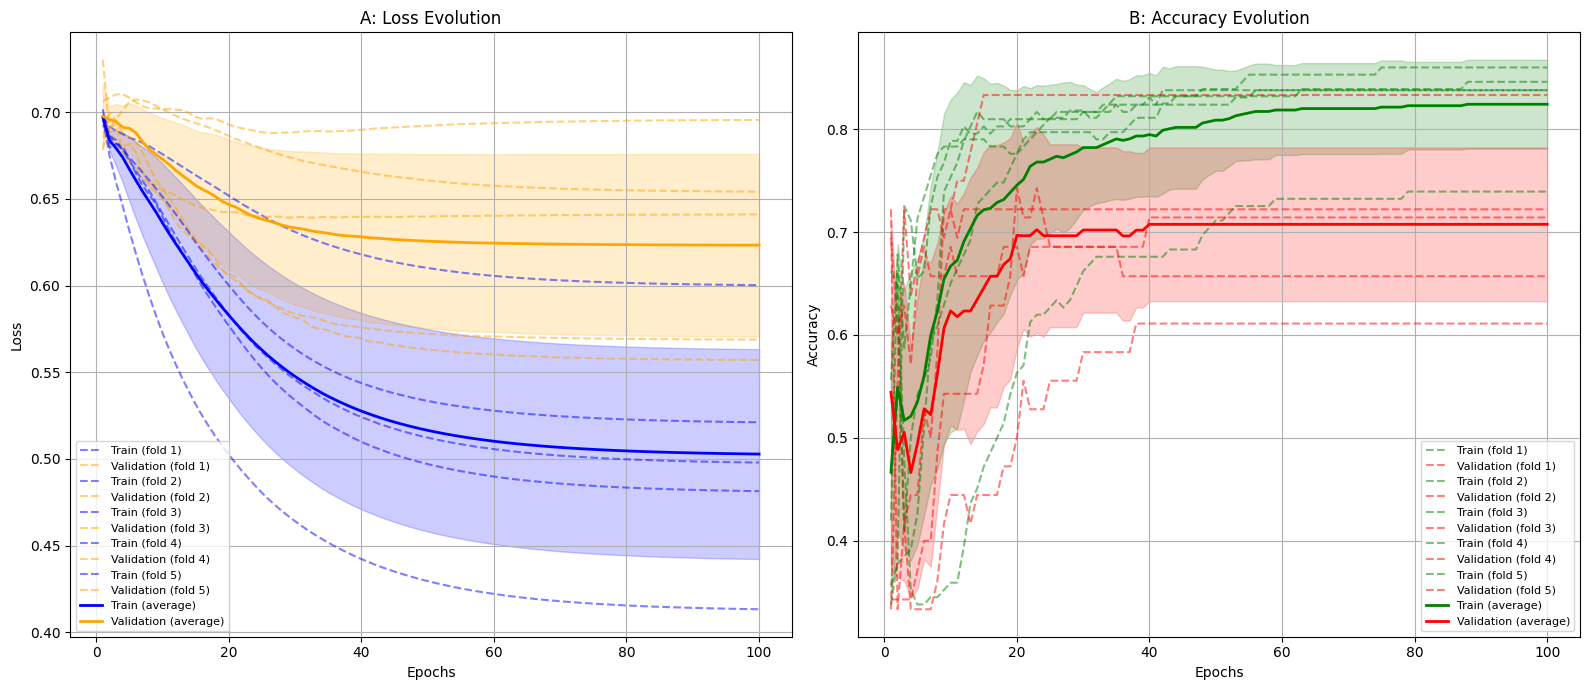

In [ ]:
epochs = 100
epochs_range = range(1, epochs + 1)

fold_train_loss = np.loadtxt("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/fold_train_loss.txt")
fold_val_loss = np.loadtxt("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/fold_val_loss.txt")
fold_train_acc = np.loadtxt("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/fold_train_acc.txt")
fold_val_acc = np.loadtxt("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/fold_val_acc.txt")

#==========================#
# Avareges and desviations #
#==========================#

mean_train_loss = np.mean(fold_train_loss, axis=0)
std_train_loss = np.std(fold_train_loss, axis=0)
mean_val_loss = np.mean(fold_val_loss, axis=0)
std_val_loss = np.std(fold_val_loss, axis=0)

mean_train_acc = np.mean(fold_train_acc, axis=0)
std_train_acc = np.std(fold_train_acc, axis=0)
mean_val_acc = np.mean(fold_val_acc, axis=0)
std_val_acc = np.std(fold_val_acc, axis=0)


plt.figure(figsize=(16, 7))

#============#
# Loss graph #
#============#

plt.subplot(1, 2, 1)
for i, (train_loss, val_loss) in enumerate(zip(fold_train_loss, fold_val_loss)):
    plt.plot(epochs_range, train_loss, '--', label=f"Train (fold {i+1})", alpha=0.5, color='blue')
    plt.plot(epochs_range, val_loss, '--', label=f"Validation (fold {i+1})", alpha=0.5, color='orange')

plt.plot(epochs_range, mean_train_loss, label='Train (average)', color='blue', linewidth=2)
plt.fill_between(epochs_range, mean_train_loss - std_train_loss, mean_train_loss + std_train_loss, color='blue', alpha=0.2)
plt.plot(epochs_range, mean_val_loss, label='Validation (average)', color='orange', linewidth=2)
plt.fill_between(epochs_range, mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, color='orange', alpha=0.2)

plt.title("A: Loss Evolution")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc="best", fontsize=8)
plt.grid()

#================#
# Accuracy graph #
#================#

plt.subplot(1, 2, 2)
for i, (train_acc, val_acc) in enumerate(zip(fold_train_acc, fold_val_acc)):
    plt.plot(epochs_range, train_acc, '--', label=f"Train (fold {i+1})", alpha=0.5, color='green')
    plt.plot(epochs_range, val_acc, '--', label=f"Validation (fold {i+1})", alpha=0.5, color='red')

plt.plot(epochs_range, mean_train_acc, label='Train (average)', color='green', linewidth=2)
plt.fill_between(epochs_range, mean_train_acc - std_train_acc, mean_train_acc + std_train_acc, color='green', alpha=0.2)
plt.plot(epochs_range, mean_val_acc, label='Validation (average)', color='red', linewidth=2)
plt.fill_between(epochs_range, mean_val_acc - std_val_acc, mean_val_acc + std_val_acc, color='red', alpha=0.2)

plt.title("B: Accuracy Evolution")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc="best", fontsize=8)
plt.grid()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/grafico_KFOLDS.jpeg", format="png", dpi=300)
plt.show()

# Training the network using the combined training and validation data, without providing the network with a validation set.

In [ ]:
#=============================
#Fix state for reproducibility
#=============================

i=42
os.environ['PYTHONHASHSEED']=str(i)
tf.random.set_seed(i)
np.random.seed(i)
random.seed(i)

#=======================================#
# Train and validation data concatenate #
# ======================================#

inputs = np.concatenate((X_train, X_val), axis=0)
targets = np.concatenate((y_train, y_val), axis=0)

#==========================================================#
# Calculate class weights for penalising the cost function #
#==========================================================#

weights = class_weight.compute_class_weight('balanced', classes=np.unique(targets), y=targets)


#=============
#Network Model
#=============

model = Sequential()

#Convolutional and Max Pooling layers
model.add(Conv2D(16, kernel_size=(5, 5),activation='relu',input_shape=(224, 224, 3), padding='same'))
model.add(MaxPooling2D((3, 3),padding='same'))
model.add(Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same'))
model.add(MaxPooling2D((3, 3),padding='same'))

model.add(Flatten())

#MLP Network
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

# Optimiser with exponential decay

opt = ke.optimizers.Adam(learning_rate= ke.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.00008,
    decay_steps=15,
    decay_rate=0.85))


model.compile(optimizer=opt,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ====================
# Save initial weights
# ====================

with open("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/initial_weightsconcatenate.txt", "w") as f:
    for layer in model.layers:
        pesos = layer.get_weights()
        f.write(f"Layer: {layer.name}\n")
        for p in pesos:
            f.write(str(p.tolist()) + "\n")
        f.write("\n")

batch_size = 32
epochs = 100

history= model.fit(inputs, targets, batch_size=batch_size,epochs=epochs,verbose=1,class_weight={0:weights[0], 1:weights[1]})

# ==================
# Save final weights
# ==================

with open("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/final_weightsconcatenate.txt", "w") as f:
    for layer in model.layers:
        pesos = layer.get_weights()
        f.write(f"Layer: {layer.name}\n")
        for p in pesos:
            f.write(str(p.tolist()) + "\n")
        f.write("\n")

# ==============================
# Save loss and accuracy history
# ==============================
with open("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/history_concatenate.txt", "w") as f:
    f.write("Epoch\tLoss\tAccuracy\n")  # Cabeçalho ajustado
    for epoch in range(len(history.history['loss'])):
        f.write(f"{epoch+1}\t"
                f"{history.history['loss'][epoch]:.6f}\t"
                f"{history.history['accuracy'][epoch]:.6f}\n")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 75, 75, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │       200,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,069 (836.21 KB)

 Trainable params: 214,069 (836.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 376ms/step - accuracy: 0.3707 - loss: 0.7047
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3589 - loss: 0.6964
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3759 - loss: 0.6925
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4256 - loss: 0.6891
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4916 - loss: 0.6848
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5008 - loss: 0.6800
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5635 - loss: 0.6750
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5835 - loss: 0.6701
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6256 - loss: 0.6652
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6307 - loss: 0.6602
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6450 - loss: 0.6555
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6565 - l

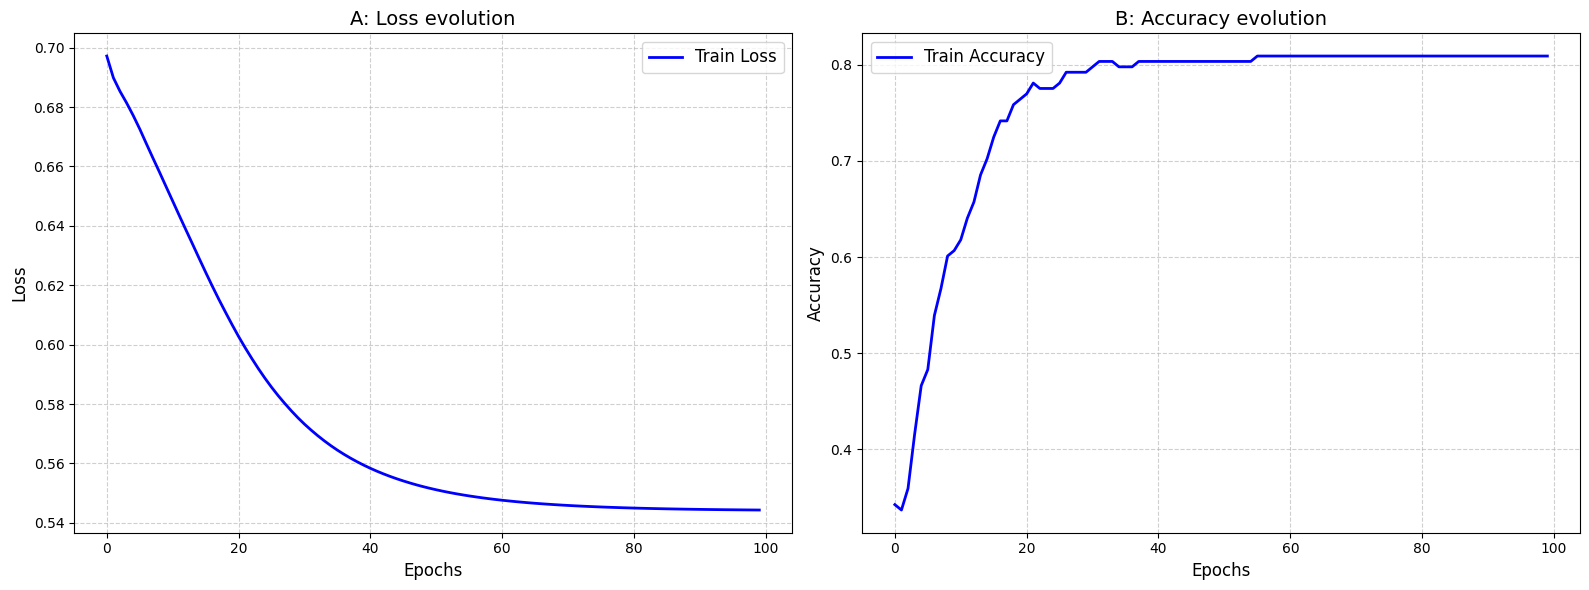

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/history_concatenate.txt", sep="\t")

# Garante que os dados sejam float (caso venha como string por erro anterior)
df["Loss"] = df["Loss"].astype(float)
df["Accuracy"] = df["Accuracy"].astype(float)

plt.figure(figsize=(16, 6))


#===========#
#Loss graph #
#===========#

plt.subplot(1, 2, 1)
plt.plot(df["Loss"], label="Train Loss", color="blue", linewidth=2)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("A: Loss evolution", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
#plt.ylim([0.3, max(df["Loss"].max()) * 1.1])

#===============
# Accuracy graph
#===============

plt.subplot(1, 2, 2)
plt.plot(df["Accuracy"], label="Train Accuracy", color="blue", linewidth=2)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("B: Accuracy evolution", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
#plt.ylim([0.3, df[["Accuracy"]].max().max() * 1.05])


plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/grafico_TREINOVALIDACAO_DOPPLER_CONCATENATE.jpeg", format="jpeg", dpi=300)

plt.show()

## Confusion Matrix

In [ ]:
#===============================================#
# Function for determining the Confusion Matrix #
#===============================================#

def mat_conf(Xmeasure, ymeasure, model, nome_dados, threshold, save_path=None):
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    import sklearn.metrics as skm

    # Model predictions
    Y_pred_prob = model.predict(Xmeasure)

    # Apply custom threshold
    Y_pred = (Y_pred_prob >= threshold).astype(int)

    # Confusion Matrix
    cmat = skm.confusion_matrix(ymeasure, Y_pred)
    cm_df = pd.DataFrame(
        cmat,
        index=['Real: Benign', 'Real: Malign'],
        columns=['Predict: Benign', 'Predict: Malign']
    )

    # Metrics
    accuracy = skm.accuracy_score(ymeasure, Y_pred)
    precision = skm.precision_score(ymeasure, Y_pred, zero_division=0)
    recall = skm.recall_score(ymeasure, Y_pred, zero_division=0)
    f1 = skm.f1_score(ymeasure, Y_pred, zero_division=0)

    # Plot
    plt.figure(figsize=(6, 6))
    ax = sns.heatmap(cm_df, annot=True, fmt="d", cmap='Blues', cbar=False, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix: {nome_dados}', fontsize=14)
    plt.xlabel('Predict Class', fontsize=12)
    plt.ylabel('Real Class', fontsize=12)

    plt.text(0.5, -0.3, f'Accuracy: {accuracy:.2f}', ha='center', va='center', transform=ax.transAxes, fontsize=10)
    plt.text(0.5, -0.4, f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}',
             ha='center', va='center', transform=ax.transAxes, fontsize=10)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')

    plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 495ms/step


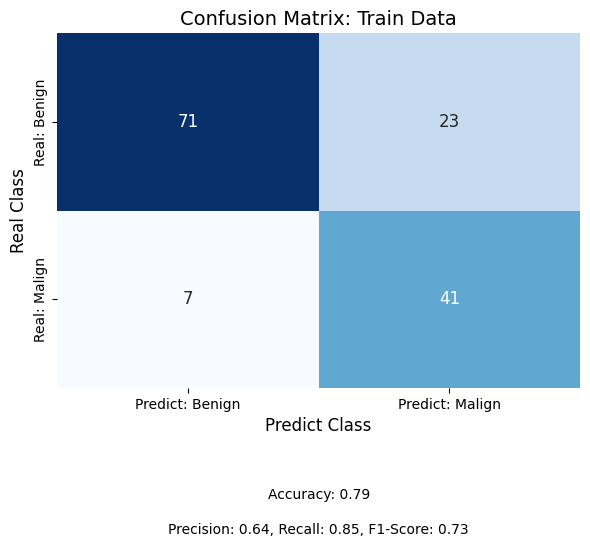

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


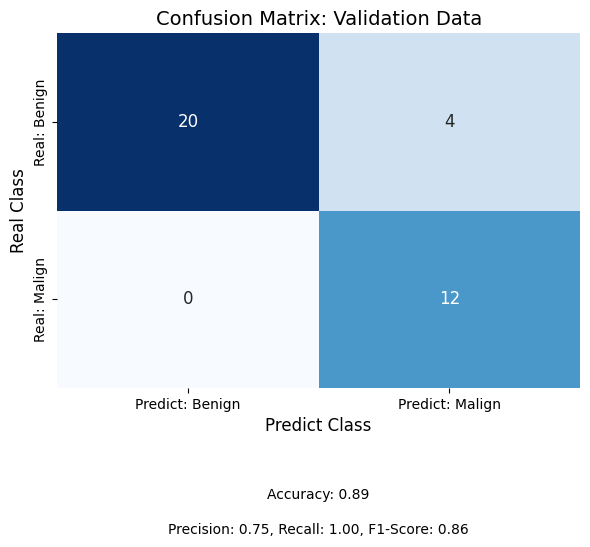

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step


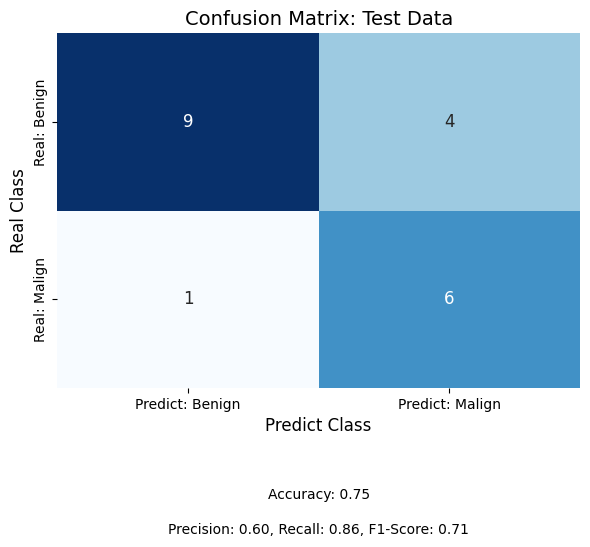

In [ ]:
mat_conf(X_train, y_train, model, "Train Data", 0.5, save_path="/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/matriz_confusao_treino.png")
mat_conf(X_val, y_val, model, "Validation Data", 0.5, save_path="/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/matriz_confusao_val.png")
mat_conf(X_test, y_test, model, "Test Data", 0.5, save_path="/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/matriz_confusao_teste.png")

## ROC curve and AUC

In [ ]:
lr_probs = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


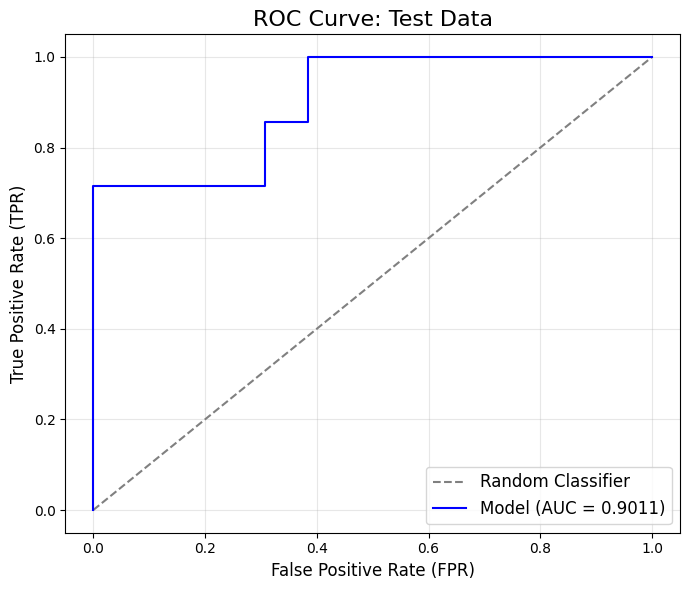

In [ ]:
#===================#
# ROC Curve and AUC #
#===================#

lr_auc = roc_auc_score(y_test, lr_probs)
fpr, tpr, thresholds = roc_curve(y_test, lr_probs)
auc_cnn = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

# Random Classifier

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

plt.plot(fpr, tpr, color='blue', label=f'Model (AUC = {auc_cnn:.4f})')

plt.title('ROC Curve: Test Data', fontsize=16)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)

save_path = "/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/curvarocteste.png"


plt.tight_layout()
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')  # Salvando como JPEG


plt.show()


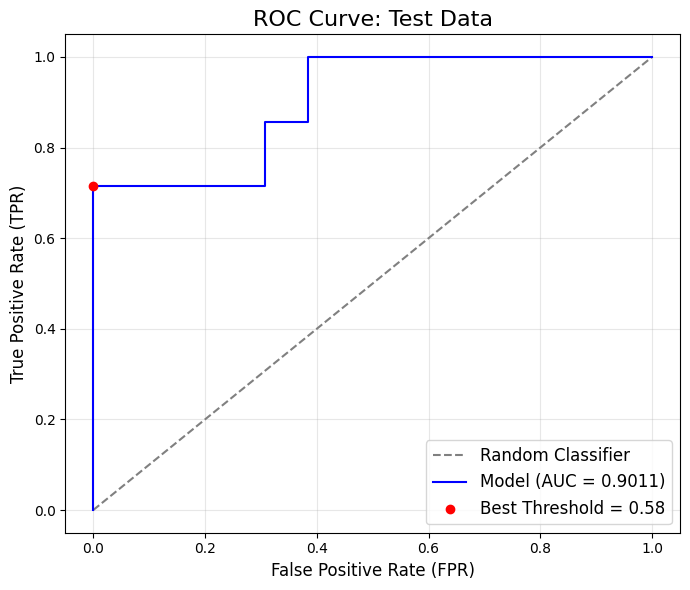

In [ ]:
#===========================================#
# The best threshold (Youden's J statistic) #
#===========================================#

lr_auc = roc_auc_score(y_test, lr_probs)
fpr, tpr, thresholds = roc_curve(y_test, lr_probs)
auc_cnn = auc(fpr, tpr)

j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]

plt.figure(figsize=(7, 6))

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

plt.plot(fpr, tpr, color='blue', label=f'Model (AUC = {auc_cnn:.4f})')

plt.scatter(fpr[best_index], tpr[best_index], color='red', label=f'Best Threshold = {best_threshold:.2f}', zorder=10)

plt.title('ROC Curve: Test Data', fontsize=16)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
save_path = "/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/curvarocteste_threshold.png"  # Nome do arquivo
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')

plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


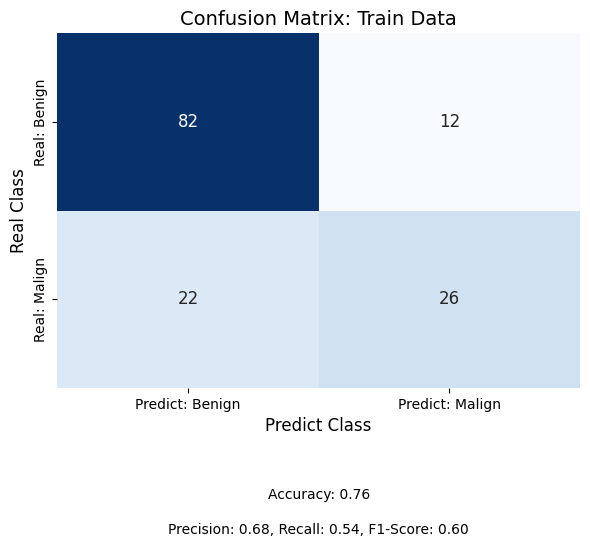

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


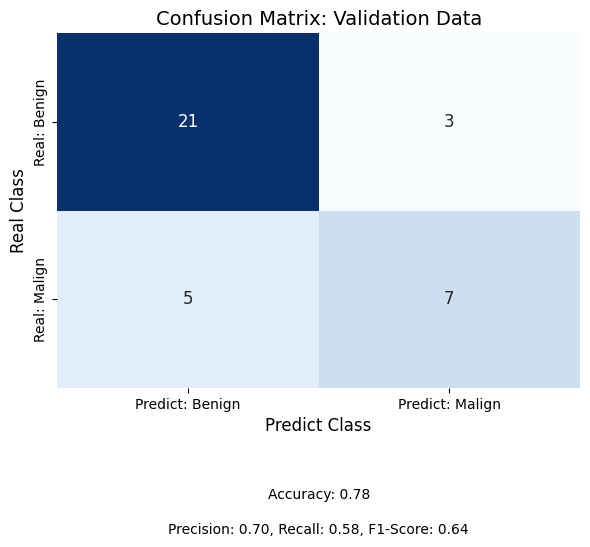

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


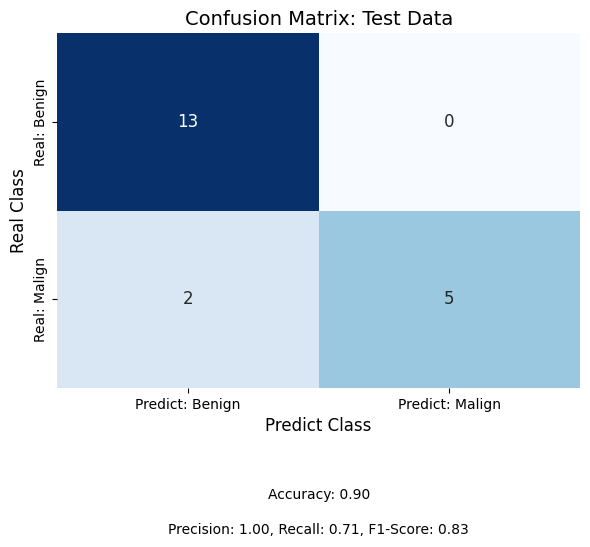

In [ ]:
mat_conf(X_train, y_train, model, "Train Data", 0.58, save_path="/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/matriz_confusao_treinoTHRESHOLD.png")
mat_conf(X_val, y_val, model, "Validation Data", 0.58, save_path="/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/matriz_confusao_valTHRESHOLD.png")
mat_conf(X_test, y_test, model, "Test Data", 0.58, save_path="/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/matriz_confusao_testeTHRESHOLD.png")

## Predicted Probabilities Graph

In [ ]:
y_pred_prob = model.predict(X_test).flatten()  # Predicted probabilities
y_test = y_test.flatten()  # Real class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


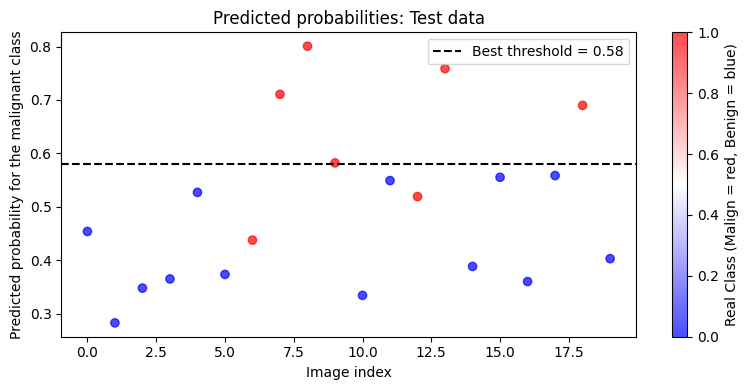

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(range(len(y_pred_prob)), y_pred_prob, c=y_test, cmap='bwr', alpha=0.7)
plt.axhline(y=0.58, color='black', linestyle='--', label='Best threshold = 0.58')
plt.title("Predicted probabilities: Test data")
plt.xlabel("Image index")
plt.ylabel("Predicted probability for the malignant class")
plt.colorbar(label="Real Class (Malign = red, Benign = blue)")
plt.legend()
plt.tight_layout()
save_path = "/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/Probabilidadetreino.jpeg"
plt.savefig(save_path, format='jpeg', dpi=300, bbox_inches='tight')

plt.show()

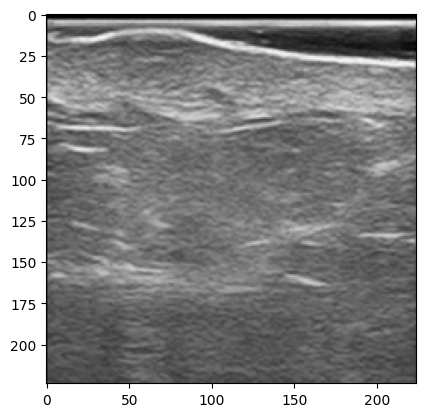

In [ ]:
plt.imshow(X_train[6])

In [ ]:
model.save('/content/drive/MyDrive/Artigo_Visao_Computacional/Modelos_Isabela/ArqBW/TESTE/modelBW.h5')